In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

d:\Projects\Data Science\Langchain\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
load_dotenv()

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

In [3]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [4]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = llm.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [5]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = llm.invoke(prompt).content

    state['content'] = content

    return state

In [6]:


graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()



In [7]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

In [8]:
print(final_state['outline'])

Here's a detailed outline for a blog post on "The Rise of AI in India," designed to be engaging, informative, and well-structured.

---

## Blog Title Options:

*   **The AI Awakening: Decoding India's Rapid Ascent in Artificial Intelligence**
*   **India's AI Revolution: From Silicon Valley to Bharat's Villages**
*   **Shaping Tomorrow: How AI is Redefining India's Future**
*   **Beyond the Hype: The Real Story of AI's Rise in India**

---

## Blog Outline: The Rise of AI in India

**Target Audience:** General tech enthusiasts, business professionals, policymakers, students, and anyone interested in India's digital transformation.

**Tone:** Informative, optimistic but balanced, analytical, forward-looking.

**Keywords:** AI India, Artificial Intelligence India, India tech, digital India, AI applications India, AI challenges India, NITI Aayog AI, Indian startups AI, AI future India.

---

### I. Introduction (Approx. 150 words)

*   **A. Catchy Hook:** Start with a striking statement 

In [9]:
print(final_state['content'])

## The AI Awakening: Decoding India's Rapid Ascent in Artificial Intelligence

Once known globally for its outsourcing prowess and a vast talent pool supporting tech giants abroad, India is now scripting a new, more ambitious narrative: that of an AI powerhouse. We are witnessing a fundamental shift, where Artificial Intelligence is no longer a futuristic concept but a tangible force rapidly reshaping every facet of Indian society and economy.

At its core, Artificial Intelligence refers to the development of computer systems capable of performing tasks that typically require human intelligence. This includes learning, problem-solving, understanding language, recognizing patterns, and making decisions. In India, AI is not just about adopting global trends; it's about innovating locally, addressing unique challenges, and building an AI ecosystem that truly serves "Bharat." This blog delves into the unique factors fueling AI's rapid transformation across India, exploring the immense oppo

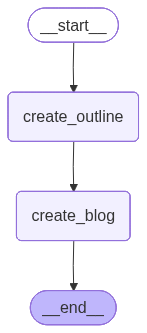

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())